In [19]:
from langgraph.graph import StateGraph,END
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from langchain_ollama import ChatOllama
from typing import TypedDict
import json
import re
import os
import random

In [20]:
llm = ChatOllama(model="llama3.2", num_predict=512, temperature=0)

In [21]:
TRAITS = ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]

class AssessmentState(TypedDict):
    messages: list
    scrubbed_input: str
    trait_scores: dict
    confidence: dict
    cumulative_confidence: dict
    depth_needed: str
    turn_count: int
    should_terminate: bool
    next_question: str
    final_report: dict

In [22]:
def clean_json(text: str) -> str:
    text = re.sub(r"```(?:json)?", "", text).replace("```", "")
    start = text.find("{")
    end = text.rfind("}") + 1
    if start != -1 and end > start:
        return text[start:end]
    return text.strip()

In [23]:
def pii_scrubber_node(state: AssessmentState) -> AssessmentState:
    raw = state["messages"][-1].content if state["messages"] else ""
    return {**state, "scrubbed_input": raw}

In [24]:
def state_to_json_serializable(state: AssessmentState) -> dict:
    serializable_messages = []
    for m in state["messages"]:
        if isinstance(m, HumanMessage):
            role = "human"
        elif isinstance(m, AIMessage):
            role = "ai"
        else:
            role = "unknown"
        serializable_messages.append({"type": role, "content": m.content})
    return {**state, "messages": serializable_messages}

In [25]:
def json_serializable_to_state(data: dict) -> AssessmentState:
    messages = []
    for m in data.get("messages", []):
        if m["type"] == "human":
            messages.append(HumanMessage(content=m["content"]))
        elif m["type"] == "ai":
            messages.append(AIMessage(content=m["content"]))

    return {
        "messages": messages,
        "scrubbed_input": data.get("scrubbed_input", ""),
        "trait_scores": data.get("trait_scores", {}),
        "confidence": data.get("confidence", {}),
        "cumulative_confidence": data.get(
            "cumulative_confidence",
            {t: 0.0 for t in TRAITS},
        ),
        "depth_needed": data.get("depth_needed", random.choice(TRAITS)),
        "turn_count": data.get("turn_count", 0),
        "should_terminate": data.get("should_terminate", False),
        "next_question": data.get("next_question", ""),
        "final_report": data.get("final_report", {}),
    }

In [26]:
STATE_FILE = "assessment_state.json"
MIN_RESPONSE_WORDS = 5

def load_state() -> AssessmentState:
    if os.path.exists(STATE_FILE):
        try:
            with open(STATE_FILE, "r") as f:
                data = json.load(f)
            return json_serializable_to_state(data)
        except Exception:
            print("Corrupted state file. Resetting...")
    return {
        "messages": [],
        "scrubbed_input": "",
        "trait_scores": {},
        "confidence": {},
        "cumulative_confidence": {t: 0.0 for t in TRAITS},
        "depth_needed": random.choice(TRAITS),  # FIX: random start, not always "openness"
        "turn_count": 0,
        "should_terminate": False,
        "next_question": "",
        "final_report": {},
    }

In [27]:
def save_state(state: AssessmentState) -> None:
    with open(STATE_FILE, "w") as f:
        json.dump(state_to_json_serializable(state), f, indent=2)

In [28]:
def evaluation_node(state: AssessmentState) -> AssessmentState:
    # FIX: minimum input length guard — short replies don't trigger a full evaluation
    last_user_msg = state["messages"][-1].content if state["messages"] else ""
    if len(last_user_msg.split()) < MIN_RESPONSE_WORDS:
        print(f"  Short response ({len(last_user_msg.split())} words) — skipping evaluation, asking for elaboration.")
        return {
            **state,
            "should_terminate": False,
            "depth_needed": state["depth_needed"],
            "next_question": "Could you elaborate a little more on that?",
        }

    history_text = "\n".join(
        f"{m.type.capitalize()}: {m.content[:400]}"
        for m in state["messages"][-6:]
    )

    prompt = (
        "You are a psychometric analyst. Analyze the conversation below and score personality traits.\n\n"
        f"Conversation:\n{history_text}\n\n"
        "Based on everything the user has said, fill in this JSON with non-zero values.\n"
        "Every trait MUST have a non-zero score if the user said anything at all.\n"
        "Confidence should reflect how clearly each trait is expressed — minimum 0.3 if any signal exists.\n\n"
        '{"trait_updates":{"openness":0.0,"conscientiousness":0.0,"extraversion":0.0,"agreeableness":0.0,"neuroticism":0.0},'
        '"confidence":{"openness":0.0,"conscientiousness":0.0,"extraversion":0.0,"agreeableness":0.0,"neuroticism":0.0},'
        '"depth_needed":"openness","should_terminate":false}'
        "\n\nReturn ONLY the filled JSON:"
    )

    for attempt in range(2):
        response = llm.invoke([
            SystemMessage(content="You are a JSON-only psychometric engine. Always return non-zero values when user has spoken. Return ONLY valid JSON."),
            HumanMessage(content=prompt),
        ])
        raw = response.content
        print("RAW:", repr(raw[:300]))

        try:
            data = json.loads(clean_json(raw))
            trait_vals = list(data["trait_updates"].values())

            if all(v == 0.0 for v in trait_vals):
                print(f"  All zeros detected (attempt {attempt + 1}) — retrying..." if attempt == 0 else "  All zeros on retry — skipping update.")
                if attempt == 1:
                    return {**state}
                continue

            break  # valid non-zero response
        except (json.JSONDecodeError, KeyError) as e:
            print(f"  Parse failed (attempt {attempt + 1}):", e, "| raw:", raw[:200])
            if attempt == 1:
                return {**state}
            continue

    # FIX: adaptive weighting — trust new data more as we accumulate turns
    turn = state["turn_count"]
    new_weight = min(0.3 + turn * 0.05, 0.6)   # grows from 0.30 → 0.60 over 6 turns
    old_weight = 1.0 - new_weight

    updated_traits = {}
    for trait, new_val in data["trait_updates"].items():
        old_val = state["trait_scores"].get(trait, 0.0)
        updated_traits[trait] = round(old_val * old_weight + new_val * new_weight, 3)

    # Cumulative confidence — never drops
    updated_cumulative = {}
    for trait, new_conf in data["confidence"].items():
        old_conf = state["cumulative_confidence"].get(trait, 0.0)
        updated_cumulative[trait] = round(max(old_conf, new_conf), 3)

    # FIX: tie-safe depth selection — pick randomly among traits sharing the minimum confidence
    min_conf = min(updated_cumulative.values())
    weakest_traits = [t for t, v in updated_cumulative.items() if v == min_conf]
    depth_needed = random.choice(weakest_traits)

    # Terminate when all traits >= 0.7 and at least 5 turns completed
    all_confident = all(v >= 0.7 for v in updated_cumulative.values())
    should_terminate = all_confident and state["turn_count"] >= 4

    print(f"  Cumulative confidence: {updated_cumulative}")
    print(f"  Next probe: {depth_needed} | Terminate: {should_terminate} | Weight new={new_weight:.2f}")

    return {
        **state,
        "trait_scores": updated_traits,
        "confidence": data["confidence"],
        "cumulative_confidence": updated_cumulative,
        "depth_needed": depth_needed,
        "should_terminate": should_terminate,
        "turn_count": state["turn_count"] + 1,
    }


In [29]:
def question_generator_node(state: AssessmentState) -> AssessmentState:
    if state.get("next_question"):
        return state

    history_text = "\n".join(
        f"{m.type.capitalize()}: {m.content[:400]}"
        for m in state["messages"][-6:]
    )
    previous_questions = [
        m.content for m in state["messages"] if isinstance(m, AIMessage)
    ]
    previous_questions_text = "\n".join(f"- {q}" for q in previous_questions) or "None"

    prompt = (
        f"You are a psychometric interviewer. Based on the conversation history below, "
        f"and knowing that we need more information about the user's '{state['depth_needed']}' trait, "
        "formulate a follow-up question. "
        "Keep it open-ended and natural. Do NOT ask a yes/no question. "
        "Keep the question concise and directly related to probing the specified trait.\n\n"
        f"Conversation history:\n{history_text}\n\n"
        f"Questions already asked (DO NOT repeat or rephrase any of these):\n{previous_questions_text}\n\n"
        f"Generate a FRESH question that probes for '{state['depth_needed']}'.\n"
        "Return ONLY the question."
    )

    response = llm.invoke([
        SystemMessage(content="You are a helpful psychometric interviewer. You ask concise, open-ended questions."),
        HumanMessage(content=prompt),
    ])
    return {**state, "next_question": response.content}

In [30]:
def final_report_node(state: AssessmentState) -> AssessmentState:
    trait_scores = state["trait_scores"]
    cumulative_confidence = state["cumulative_confidence"]

    report_content = (
        "Based on our conversation, here is a summary of your personality traits:\n\n"
        "Trait Scores:\n"
    )
    for trait, score in trait_scores.items():
        report_content += (
            f"- {trait.capitalize()}: {score:.2f} "
            f"(Confidence: {cumulative_confidence.get(trait, 0.0):.2f})\n"
        )

    prompt = (
        "You are a psychometric analyst. Summarize the following trait assessment into a professional, concise, and empathetic report.\n"
        "Focus on presenting the scores and confidence levels in a clear and understandable manner. Do not invent information.\n\n"
        f"{report_content}\n\n"
        "Also, suggest one general area for personal growth based on the lowest scoring trait (if confidence is high enough for that trait).\n"
        "Return ONLY the report."
    )
    response = llm.invoke([
        SystemMessage(content="You are a professional psychometric report generator. Generate concise and empathetic reports."),
        HumanMessage(content=prompt),
    ])
    return {**state, "final_report": {"content": response.content}}


In [31]:
workflow = StateGraph(AssessmentState)

workflow.add_node("scrubber", pii_scrubber_node)
workflow.add_node("evaluator", evaluation_node)
workflow.add_node("question_generator", question_generator_node)
workflow.add_node("final_reporter", final_report_node)

workflow.set_entry_point("scrubber")
workflow.add_edge("scrubber", "evaluator")

workflow.add_conditional_edges(
    "evaluator",
    lambda state: "final_reporter" if state["should_terminate"] else "question_generator",
    {"question_generator": "question_generator", "final_reporter": "final_reporter"},
)

workflow.add_edge("question_generator", END)
workflow.add_edge("final_reporter", END)

app = workflow.compile()

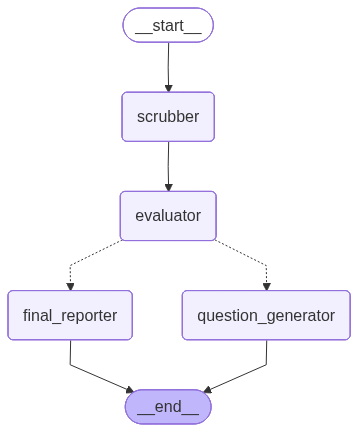

In [32]:
app

In [33]:
def run_assessment_turn(user_input: str) -> AssessmentState:
    state = load_state()
    state["next_question"] = ""
    state["messages"].append(HumanMessage(content=user_input))

    result = app.invoke(state)

    # Store AI response into message history so it's available as context next turn
    if result.get("should_terminate"):
        ai_output = result.get("final_report", {}).get("content", "")
    else:
        ai_output = result.get("next_question", "")

    if ai_output:
        result["messages"].append(AIMessage(content=ai_output))

    save_state(result)
    return result


In [34]:
OPENING_QUESTION = (
    "Hello! Let's start with a broad question. "
    "Tell me about a time you had to adapt to a new situation — "
    "what was it like and how did you handle it?"
)

if __name__ == "__main__":
    if os.path.exists(STATE_FILE):
        os.remove(STATE_FILE)

    initial_state = load_state()
    initial_state["messages"].append(AIMessage(content=OPENING_QUESTION))
    save_state(initial_state)

    print(f"Assessment Bot: {OPENING_QUESTION}")

    while True:
        user_input = input("User: ").strip()
        if not user_input:
            continue

        updated_state = run_assessment_turn(user_input)

        if updated_state["should_terminate"]:
            print("\nAssessment Bot:")
            print(updated_state["final_report"].get("content", "Assessment complete."))
            break
        else:
            print("\nAssessment Bot:")
            print(updated_state.get("next_question", "Tell me more."))


Assessment Bot: Hello! Let's start with a broad question. Tell me about a time you had to adapt to a new situation — what was it like and how did you handle it?
RAW: '{"trait_updates":{"openness":0.8,"conscientiousness":0.7,"extraversion":0.2,"agreeableness":0.4,"neuroticism":0.1},"confidence":{"openness":0.6,"conscientiousness":0.5,"extraversion":0.3,"agreeableness":0.4,"neuroticism":0.2},"depth_needed":"openness","should_terminate":false}'
  Cumulative confidence: {'openness': 0.6, 'conscientiousness': 0.5, 'extraversion': 0.3, 'agreeableness': 0.4, 'neuroticism': 0.2}
  Next probe: neuroticism | Terminate: False | Weight new=0.30

Assessment Bot:
Can you think of any moments in your life where, despite adapting well to a change, you couldn't shake off the feeling that something wasn't quite right or that you were somehow "off"?
RAW: '{"trait_updates":{"openness":0.8,"conscientiousness":0.7,"extraversion":0.4,"agreeableness":0.6,"neuroticism":0.5},"confidence":{"openness":0.8,"consci